# Power Transformer

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [5]:
df=pd.read_csv('concrete_data.csv')

In [7]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [8]:
df.shape

(1030, 9)

In [9]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [10]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


# Checking Strength of Cement

In [11]:
x=df.drop(columns=['Strength'])
y=df['Strength']

In [14]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)

In [17]:
x_train.shape,x_test.shape

((824, 8), (206, 8))

### Applying Regression Without Any Transformation

In [19]:
lr = LinearRegression()

lr.fit(x_train,y_train)

y_pred=lr.predict(x_test)

r2_score(y_test,y_pred)

0.6369606518338298

In [24]:
## Cross Cheking with applying cross_val_score
lr=LinearRegression()
np.mean(cross_val_score(lr,x,y,scoring='r2'))

np.float64(0.4609940491662864)

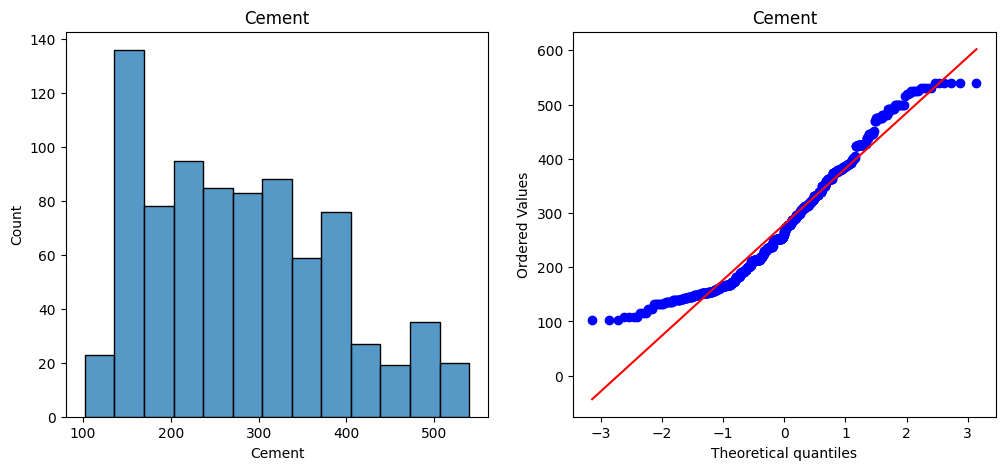

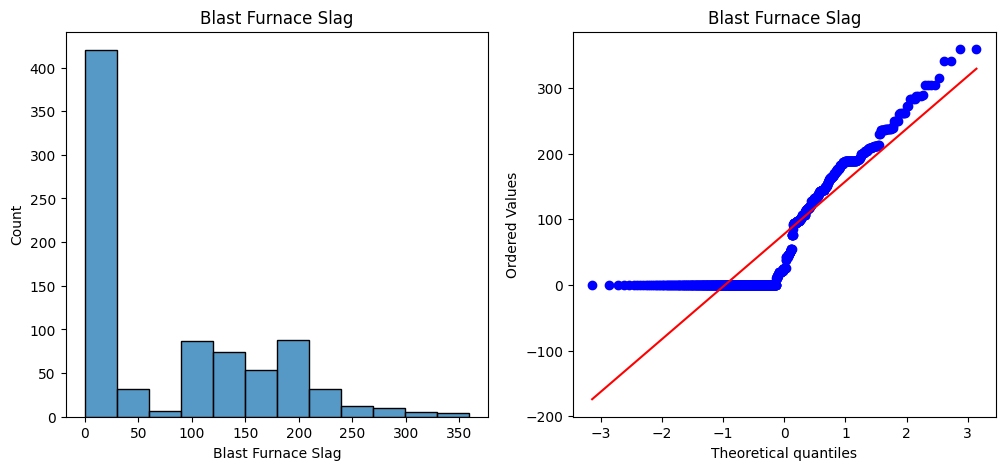

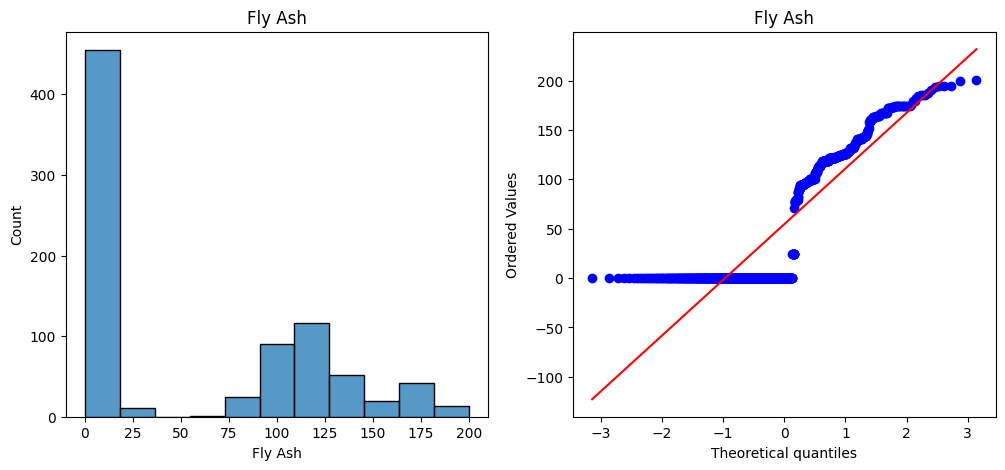

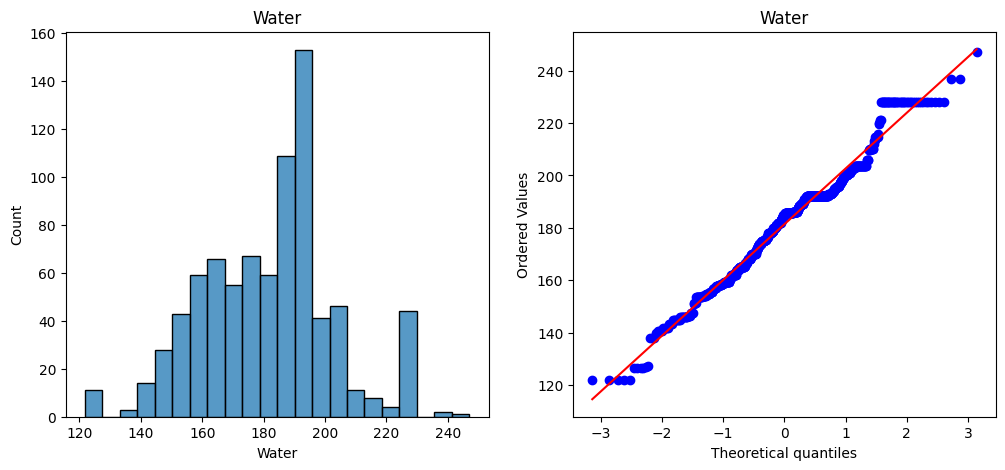

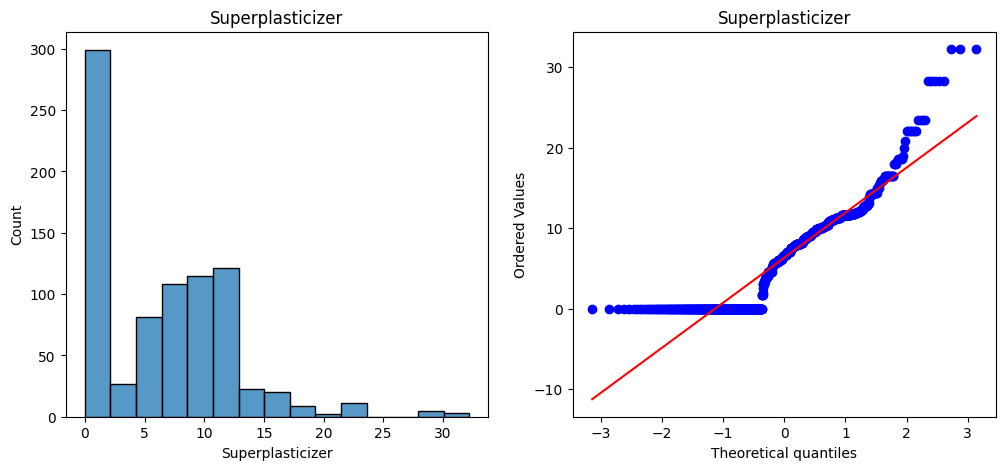

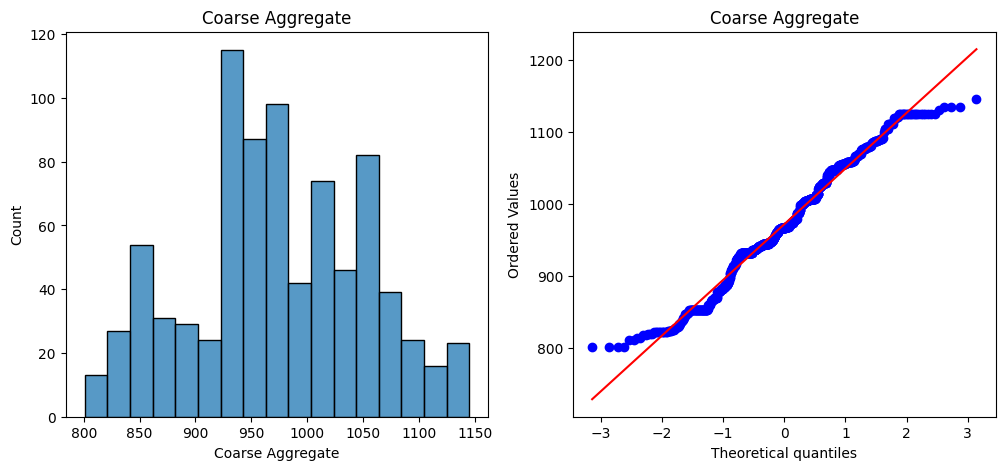

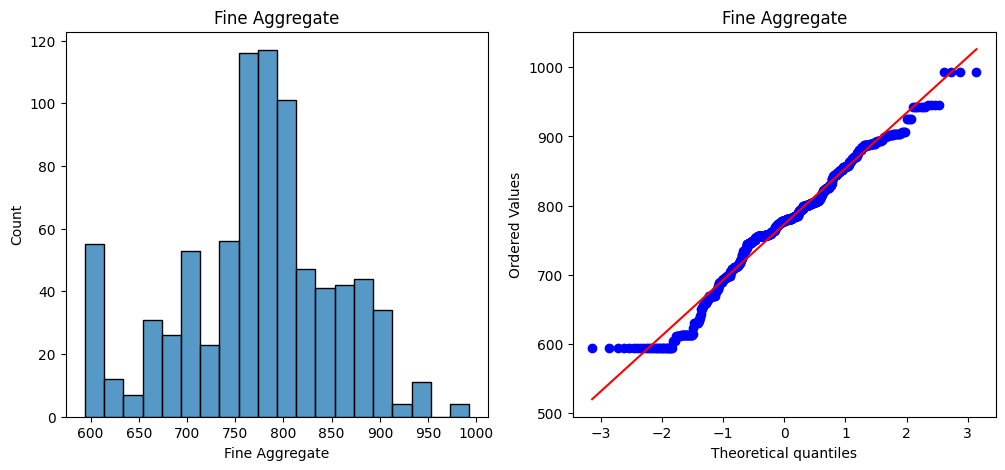

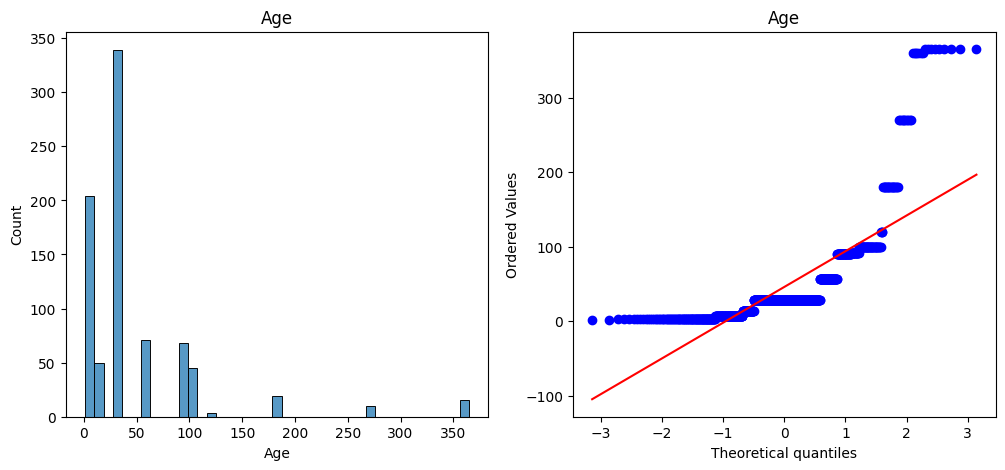

In [26]:
# ploting histplot without any transformation
for col in x_train.columns:
    plt.figure(figsize=(12,5))

    plt.subplot(121)
    sns.histplot(x_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train[col],dist='norm',plot=plt)
    plt.title(col)

    plt.show()

## Applying Box Cox Transformation

In [28]:
# Applying Box-Cox Transform

pt = PowerTransformer(method='box-cox')

x_train_transformed=pt.fit_transform(x_train+0.000001)
x_test_transformed=pt.transform(x_test+0.000001)

pd.DataFrame({'cols':x_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.153049
1,Blast Furnace Slag,0.031295
2,Fly Ash,-0.034123
3,Water,0.888072
4,Superplasticizer,0.108879
5,Coarse Aggregate,1.115681
6,Fine Aggregate,1.789591
7,Age,0.063010


In [30]:
# Applying linear regression on transformed data

lr=LinearRegression()

lr.fit(x_train_transformed,y_train)

y_pred2=lr.predict(x_test_transformed)

r2_score(y_test,y_pred2)

0.8134350083716207

In [32]:
# Using cross val score
pt=PowerTransformer(method='box-cox')
x_transformed=pt.fit_transform(x+0.000001)

lr=LinearRegression()
np.mean(cross_val_score(lr,x_transformed,y,scoring='r2'))

np.float64(0.6662950326831086)

In [33]:
x_train_transformed

array([[ 1.65047695, -1.10690884, -0.90039467, ..., -0.4640251 ,
        -0.67413369,  0.08917529],
       [ 0.9550049 , -1.10690884, -0.90039467, ...,  0.85107025,
        -0.22937878,  0.08917529],
       [ 0.38046144,  0.92567644, -0.90039467, ..., -0.98170819,
        -0.65644538,  0.08917529],
       ...,
       [-1.50616326, -1.10690884,  1.14210352, ..., -0.37428287,
         0.87161449,  0.08917529],
       [-0.24182104,  1.06286396, -0.90039467, ..., -0.3922375 ,
        -1.32134465,  0.08917529],
       [-0.80391627,  1.03029632, -0.90039467, ..., -0.54344628,
        -0.73171314,  1.12486358]], shape=(824, 8))

In [35]:
## converting x_train_transformed into data frame
x_train_transformed=pd.DataFrame(x_train_transformed,columns=x_train.columns)

In [38]:
x_train_transformed.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,1.650477,-1.106909,-0.900395,0.500141,-1.336077,-0.464025,-0.674134,0.089175
1,0.955005,-1.106909,-0.900395,0.221278,-1.336077,0.851070,-0.229379,0.089175
2,0.380461,0.925676,-0.900395,1.491628,0.640932,-0.981708,-0.656445,0.089175
3,-0.117273,-1.106909,1.111948,0.337591,0.649303,0.726634,-0.233055,-1.691811
4,1.768037,-1.106909,-0.900395,0.870449,-1.336077,1.984717,-1.870566,1.124864


## Before and after comparision for Box-Cox Plot

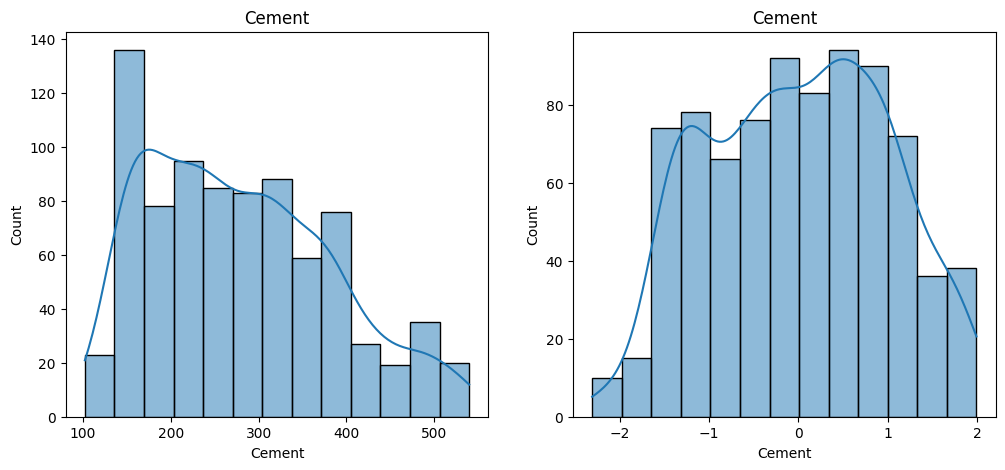

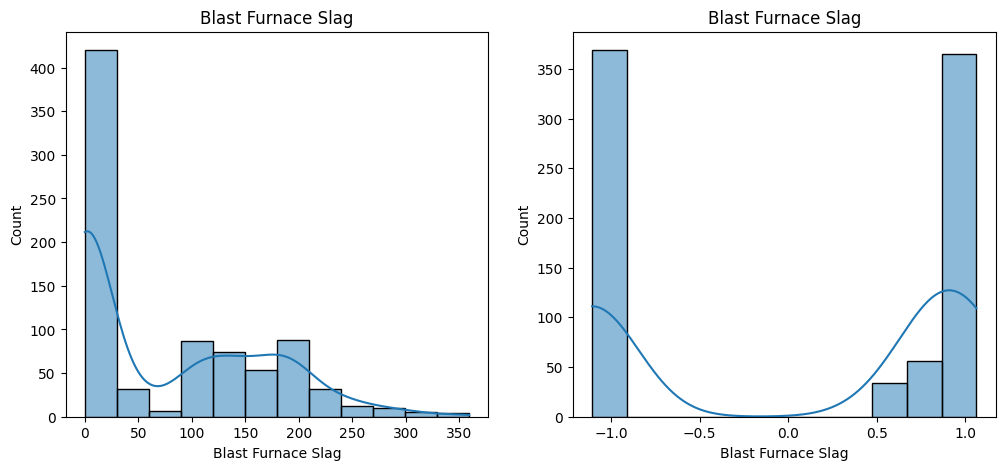

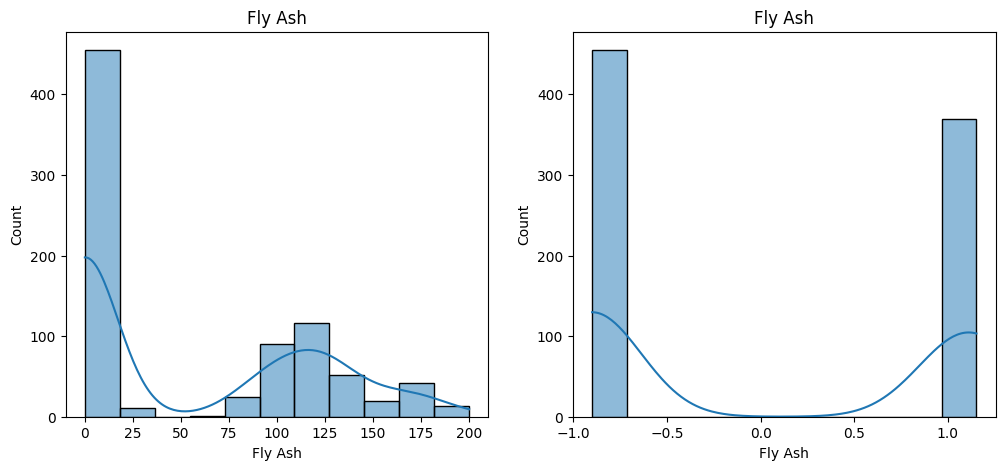

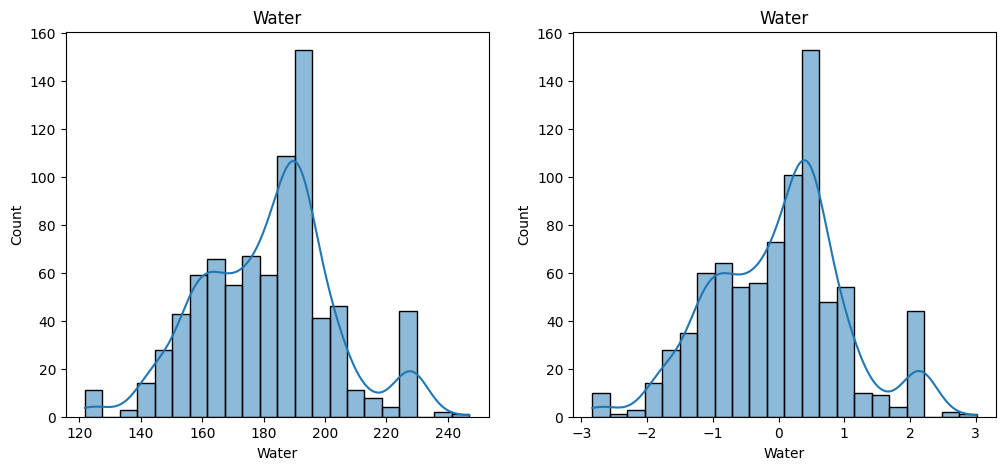

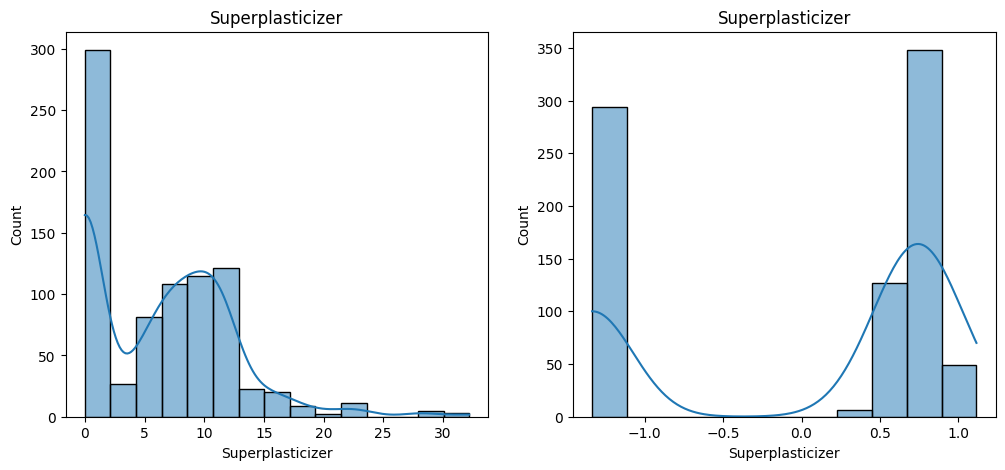

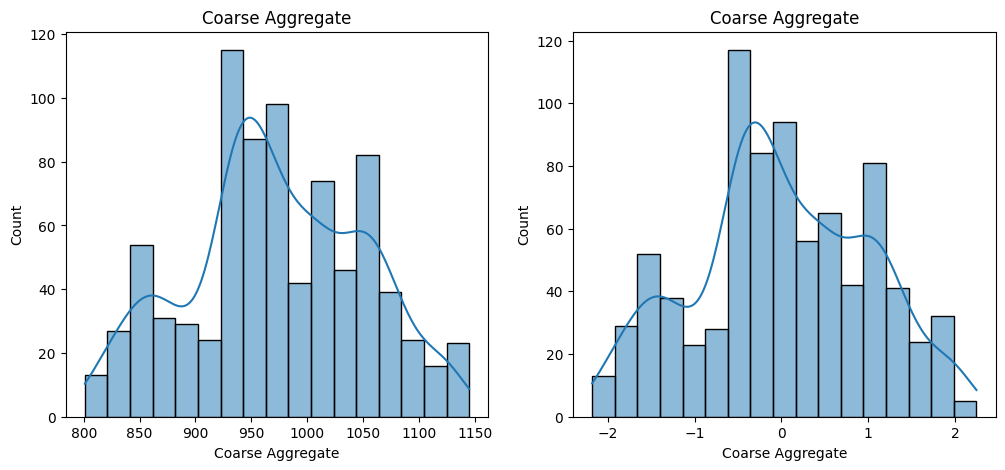

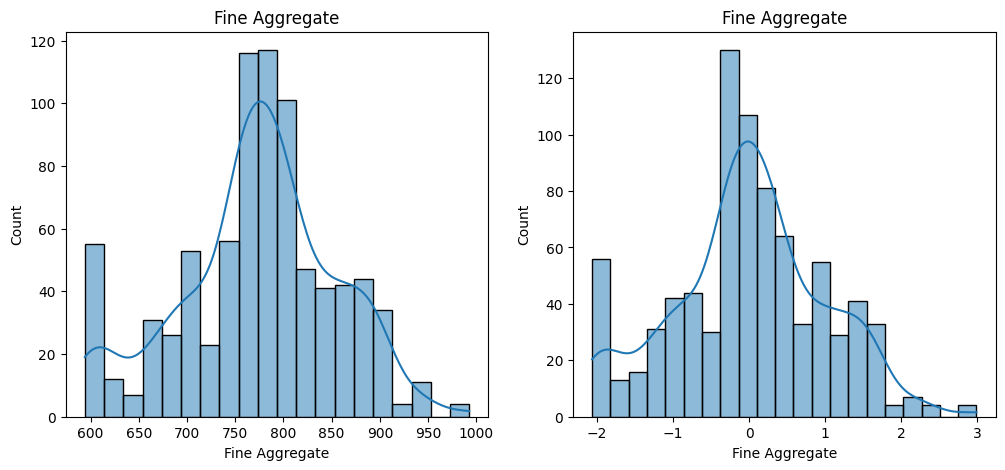

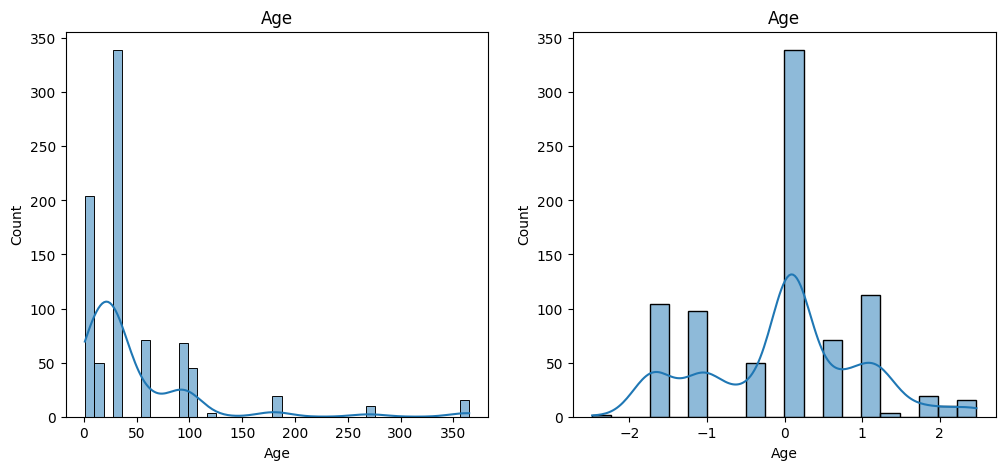

In [43]:
for col in x_train_transformed.columns:
    plt.figure(figsize=(12,5))

    plt.subplot(121)
    sns.histplot(x_train[col],kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(x_train_transformed[col],kde=True)
    plt.title(col)

    plt.show()

## Apply Yeo-Johnson transform

In [45]:
pt1=PowerTransformer()

x_train_transformed2=pt1.fit_transform(x_train)
x_test_transformed2=pt1.transform(x_test)

pd.DataFrame({'cols':x_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,Yeo_Johnson_lambdas
0,Cement,0.150260
1,Blast Furnace Slag,0.038667
2,Fly Ash,-0.141876
3,Water,0.887369
4,Superplasticizer,0.293603
5,Coarse Aggregate,1.115901
6,Fine Aggregate,1.790678
7,Age,0.016397


In [47]:
lr=LinearRegression()

lr.fit(x_train_transformed2,y_train)

y_pred3=lr.predict(x_test_transformed)

r2_score(y_test,y_pred3)

0.8197782139165446

In [49]:
## applying Cross check validation
pt=PowerTransformer()
x_trainsformed2=pt.fit_transform(x)

lr=LinearRegression()
np.mean(cross_val_score(lr,x_trainsformed2,y,scoring='r2'))

np.float64(0.6834625126992443)

In [51]:
x_train_transformed2=pd.DataFrame(x_train_transformed2,columns=x_train.columns)

In [53]:
x_train_transformed2.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,1.650593,-1.076487,-0.898159,0.500146,-1.248187,-0.464028,-0.674132,0.088917
1,0.955079,-1.076487,-0.898159,0.221283,-1.248187,0.851069,-0.229380,0.088917
2,0.380429,0.957906,-0.898159,1.491625,0.307171,-0.981708,-0.656444,0.088917
3,-0.117399,-1.076487,1.115684,0.337596,0.335731,0.726632,-0.233057,-1.679702
4,1.768145,-1.076487,-0.898159,0.870452,-1.248187,1.984729,-1.870562,1.136340


### Before and after comparision for Yeo-Johnson

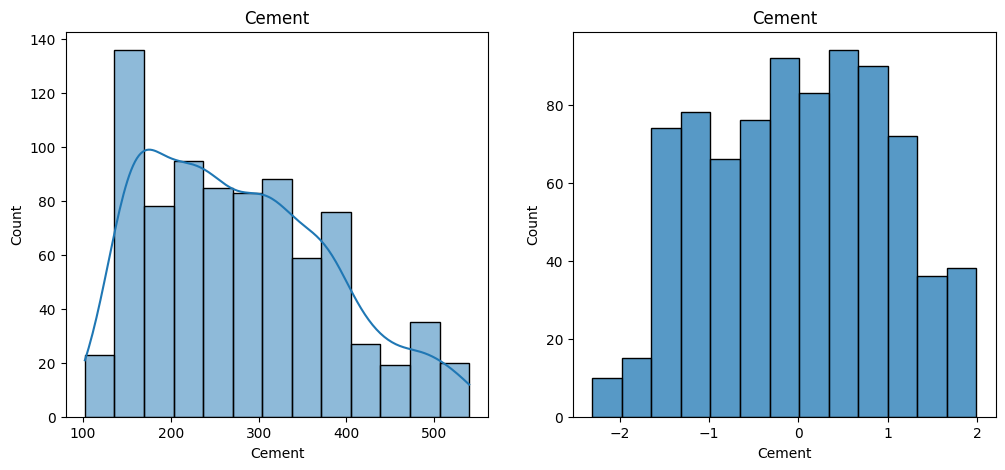

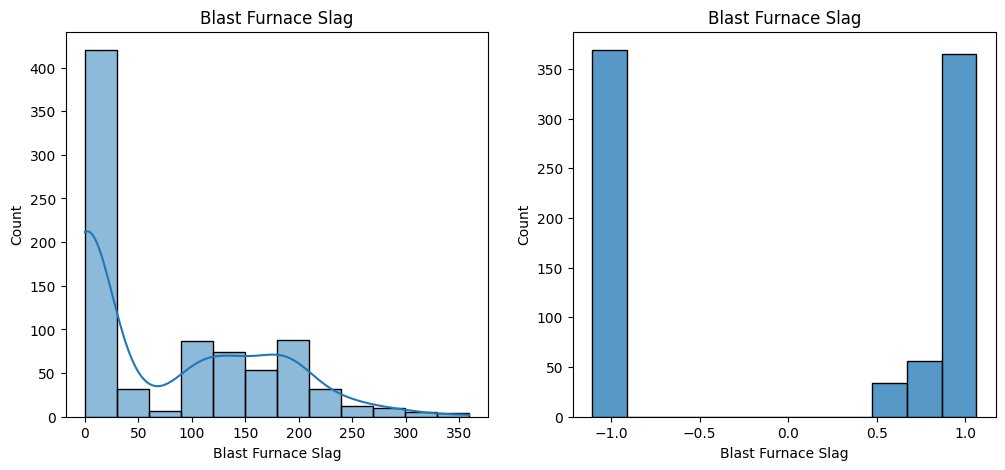

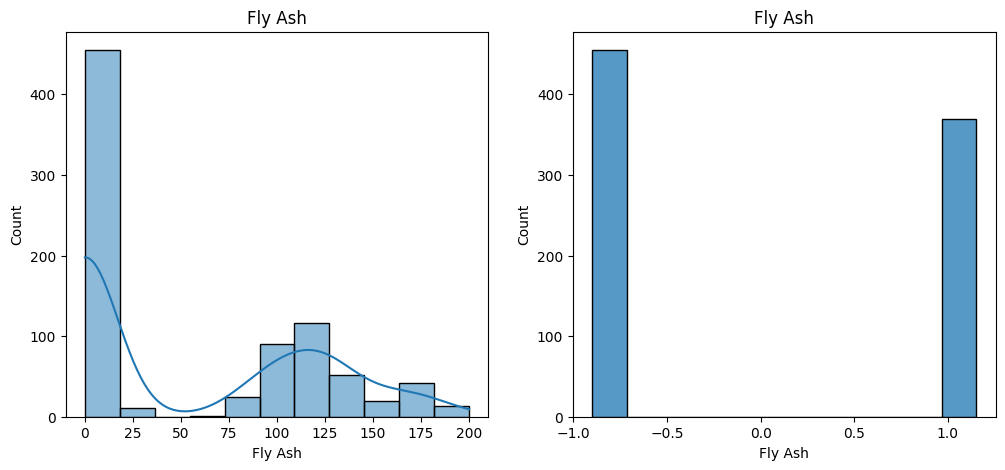

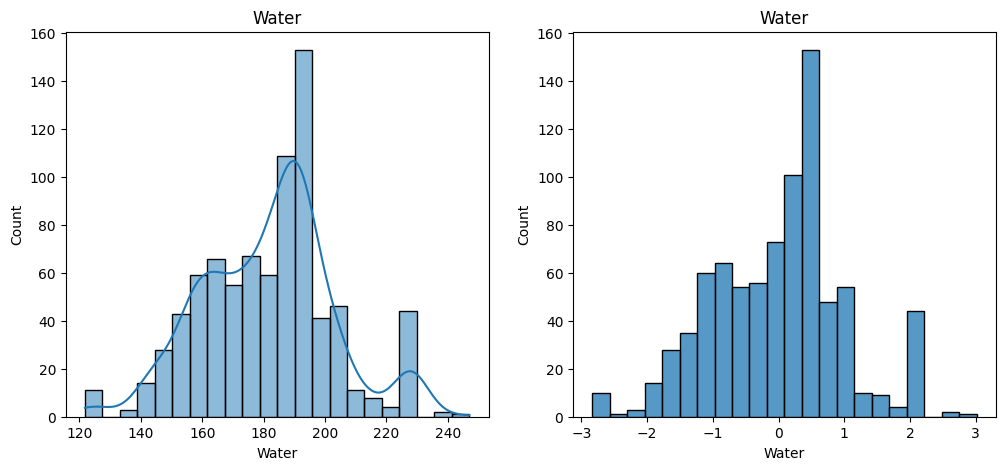

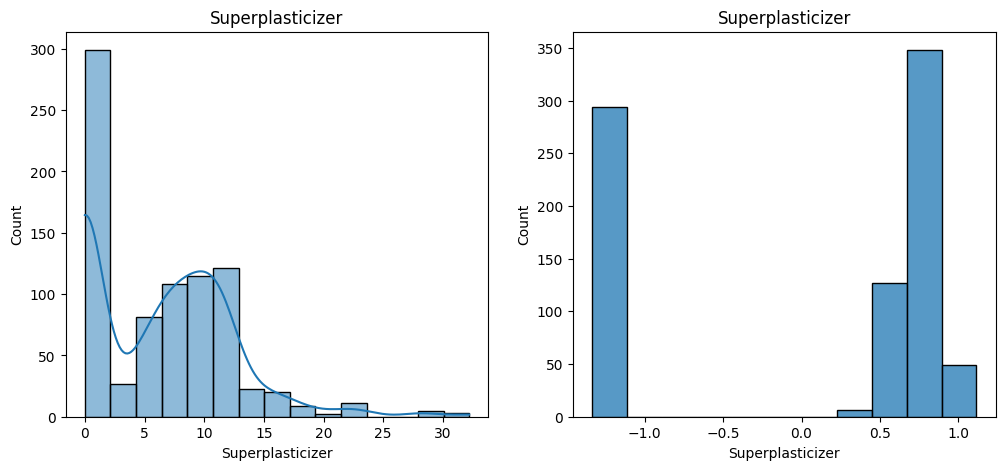

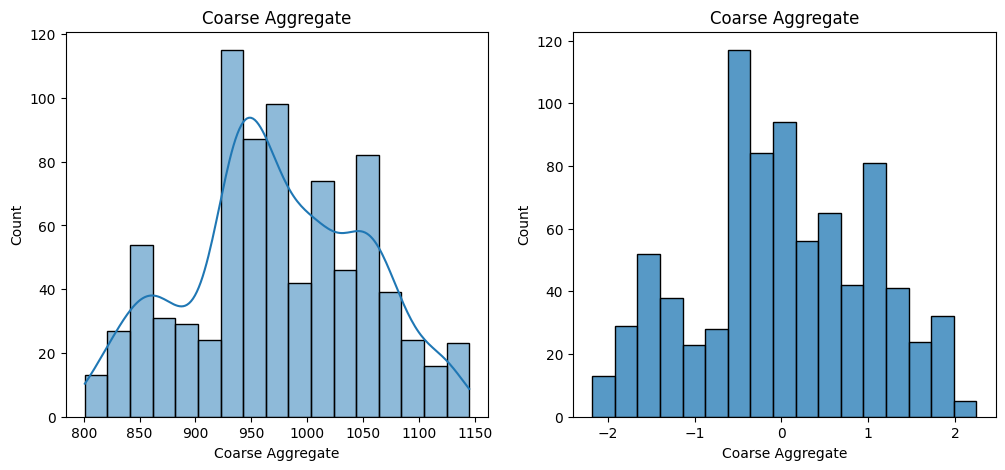

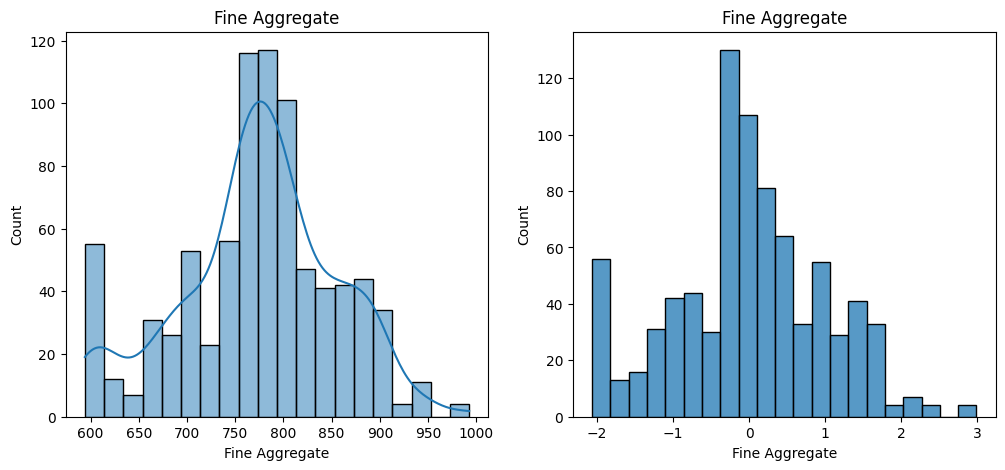

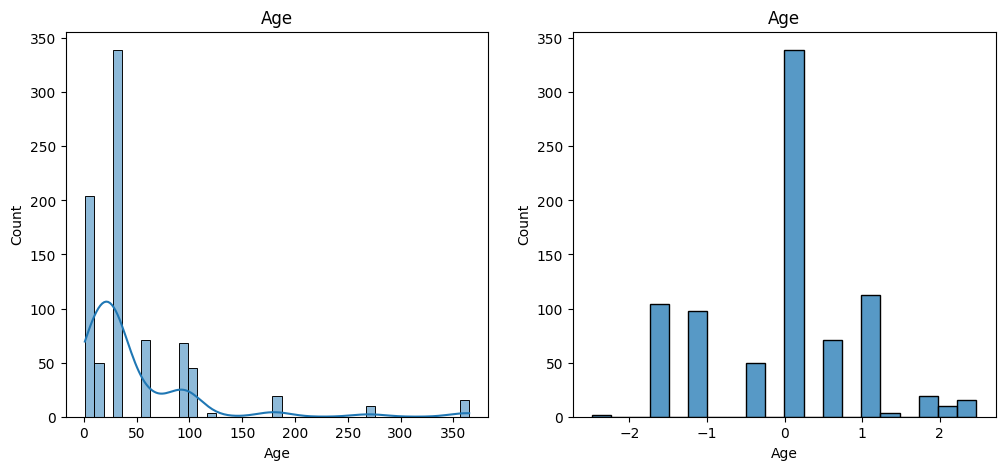

In [54]:
for col in x_train_transformed2:
    plt.figure(figsize=(12,5))

    plt.subplot(121)
    sns.histplot(x_train[col],kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(x_train_transformed[col])
    plt.title(col)

    plt.show()

In [56]:
# Side by side Lambdas
pd.DataFrame({'cols':x_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,Cement,0.169544,0.150260
1,Blast Furnace Slag,0.016633,0.038667
2,Fly Ash,-0.136480,-0.141876
3,Water,0.808438,0.887369
4,Superplasticizer,0.264160,0.293603
5,Coarse Aggregate,1.129395,1.115901
6,Fine Aggregate,1.830764,1.790678
7,Age,0.001771,0.016397
